# Black Hole Algorithm (BHA)

In [104]:
import random
import math
from typing import Callable
from tabulate import tabulate
import statistics
import platform
import sys
import os
import matplotlib.pyplot as plt

In [105]:
def get_system_specs():
    return f"{platform.system()} {platform.release()} | {platform.processor() or platform.machine()} | {os.cpu_count()} cores | Python {platform.python_version()}"

In [106]:
def compute_stats(values):
    return {
        "min":  min(values),
        "max":  max(values),
        "mean": statistics.mean(values),
        "std":  statistics.stdev(values) if len(values) > 1 else 0.0,
    }

In [107]:
def build_table(results, metric):
    algorithms = list(results.keys())
    function_names = list(results[algorithms[0]].keys())

    headers = ['function'] + algorithms
    rows = []
    for func_name in function_names:
        row = [func_name]
        for algo in algorithms:
            stats = compute_stats(results[algo][func_name])
            row.append(stats[metric])
        rows.append(row)   
    
    return headers, rows


In [108]:
def save_data(results, dimension):
    filename = f'output_{dimension}.txt'
    
    with open(filename, 'w') as out_file:
        out_file.write('system specifications\n')
        out_file.write(f'{get_system_specs()}\n\n')
        out_file.write('experiment parameters\n')
        out_file.write(f'results for dimension={dimension}, max_iterations=1000, number_of_solutions=30, number_of_runs=30\n\n')
                       
        for metric in ['mean', 'max', 'min', 'std']:
            headers, rows = build_table(results, metric)
            out_file.write(f'{metric}\n\n')
            out_file.write(tabulate(rows, headers=headers, tablefmt="github", floatfmt=".5f", colalign=('center', 'center')))
            out_file.write('\n\n')


In [109]:
def evaluate_sphere(star: list[float]) -> float:
    return sum(x ** 2 for x in star)

In [110]:
def evaluate_rosenbrock(star: list[float]) -> float:
    n = len(star)
    sum = 0.0

    for i in range(0, n - 1):
        sum += 100 * (star[i + 1] - star[i] ** 2) ** 2 + (1 - star[i]) ** 2
    
    return sum

In [111]:
def evaluate_rastrigin(star: list[float]) -> float:
    n = len(star)

    return 10 * n + sum(x ** 2 - 10 * math.cos(2 * math.pi * x) for x in star)

In [112]:
def evaluate_schwefel(star: list[float]) -> float:
    n = len(star)
    return 418.9829 * n + sum(-x * math.sin(math.sqrt(abs(x))) for x in star)

In [113]:
def evaluate_ackley(star: list[float], a: float = 20, b: float = 0.2, c: float = 2 * math.pi) -> float:
    n = len(star)

    term1 = 0
    term2 = 0

    for i in range(n):
        term1 += (star[i] ** 2)
        term2 += math.cos(c * star[i])

    term1 = -a * math.exp(-b * math.sqrt(term1 / n))
    term2 = math.exp (term2 / n)

    return term1 - term2 + a + math.e

In [114]:
def evaluate_griewank(star: list[float]) -> float:
    n = len(star)

    term1 = sum(x ** 2 for x in star) / 4000
    term2 = 1

    for i in range(n):
        term2 *= math.cos(star[i] / math.sqrt(i + 1))

    return 1 + term1 - term2

In [115]:
def initialize_star(dimension: int, lower_bound: float, upper_bound: float) -> list[float]:
    return [random.uniform(lower_bound, upper_bound) for _ in range(dimension)]

In [116]:
def black_hole_algorithm(dimension: int, max_iterations: int, star_num: int, lower_bound: float, upper_bound: float, evaluate: Callable) -> tuple[list[float], float, list[float]]:
    stars = [initialize_star(dimension, lower_bound, upper_bound) for _ in range(star_num)]
    fitness = [evaluate(star) for star in stars]

    black_hole_index = min(range(star_num), key=lambda i: fitness[i])
    black_hole = stars[black_hole_index][:]
    best_value = fitness[black_hole_index]
    
    convergence = []

    for _ in range(1, max_iterations + 1):
        for i in range(star_num):
            if i != black_hole_index:
                star = stars[i]
                rand = random.random()

                new_star = [star[j] + rand * (black_hole[j] - star[j]) for j in range(dimension)]
                new_star = [max(lower_bound, min(upper_bound, x)) for x in new_star]

                stars[i] = new_star
                fitness[i] = evaluate(new_star)
        
        current_best_index = min(range(star_num), key=lambda i: fitness[i])
        if fitness[current_best_index] < best_value:
            black_hole_index = current_best_index
            black_hole = stars[current_best_index][:]
            best_value = fitness[current_best_index]

        total_fitness = sum(fitness)
        event_horizon_radius = best_value / total_fitness if total_fitness != 0 else 0

        for i in range(star_num):
            if i != black_hole_index:
                distance  = math.sqrt(sum((stars[i][j] - black_hole[j]) ** 2 for j in range(dimension)))

                if distance < event_horizon_radius:
                    stars[i] = initialize_star(dimension, lower_bound, upper_bound)
                    fitness[i] = evaluate(stars[i])
        
        convergence.append(best_value)
    
    return black_hole, best_value, convergence

In [117]:
def run_benchmarks(benchmarks, algorithms, dimension, max_iterations=5000, pop_size=30, num_runs=30):
    results = {algo_name: {func_name: [] for func_name in benchmarks} for algo_name in algorithms}
    convergences = {algo_name: {func_name: [] for func_name in benchmarks} for algo_name in algorithms}
 
    for algo_name, algo in algorithms.items():
        for func_name, (evaluate_function, lower_bound, upper_bound) in benchmarks.items():
            for _ in range(num_runs):
                _, best_value, convergence = algo(dimension, max_iterations, pop_size, lower_bound, upper_bound, evaluate_function)
                results[algo_name][func_name].append(best_value)
                convergences[algo_name][func_name].append(convergence)
    
    return results, convergences

In [118]:
def plot_convergence(benchmarks, convergences, dimension, log_scale=True):
    func_names = list(benchmarks.keys())
    n = len(func_names)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for idx, func_name in enumerate(func_names):
        ax = axes[idx]
        for algo_name, fn_dict in convergences.items():
            runs = fn_dict[func_name]
            mean_curve = [sum(c) / len(c) for c in zip(*runs)]
            ax.plot(mean_curve, label=algo_name)
        ax.set_title(func_name)
        ax.set_xlabel("iteration")
        ax.set_ylabel("best fitness")
        if log_scale:
            ax.set_yscale("log")
        ax.legend()
        ax.grid(True, alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"convergence (dimension={dimension}, mean over runs)")
    fig.tight_layout()
    fig.savefig(f"convergence_{dimension}.png", dpi=150)

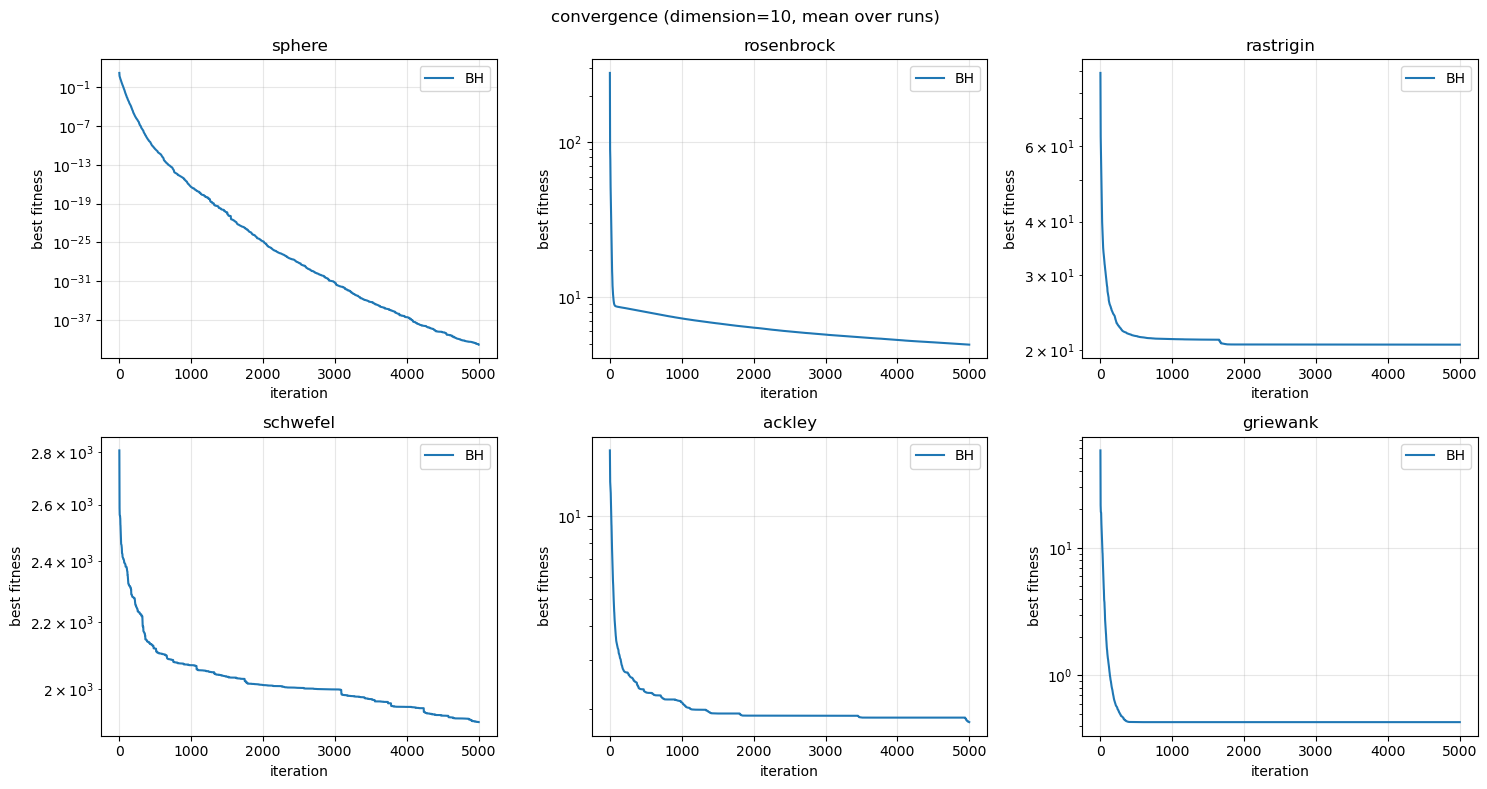

In [119]:
def main():
    dimension = 10

    benchmarks = {
        'sphere': (evaluate_sphere, -5.12, 5.12),
        'rosenbrock': (evaluate_rosenbrock, -2.048, 2.048),
        'rastrigin': (evaluate_rastrigin, -5.12, 5.12),
        'schwefel': (evaluate_schwefel, -500, 500),
        'ackley': (evaluate_ackley, -32.768, 32.768),
        'griewank': (evaluate_griewank, -600, 600)
    }

    algorithms = {
        'BH': black_hole_algorithm
    }
    
    results, convergences = run_benchmarks(benchmarks, algorithms, dimension)
    save_data(results, dimension)
    plot_convergence(benchmarks, convergences, dimension)

main()